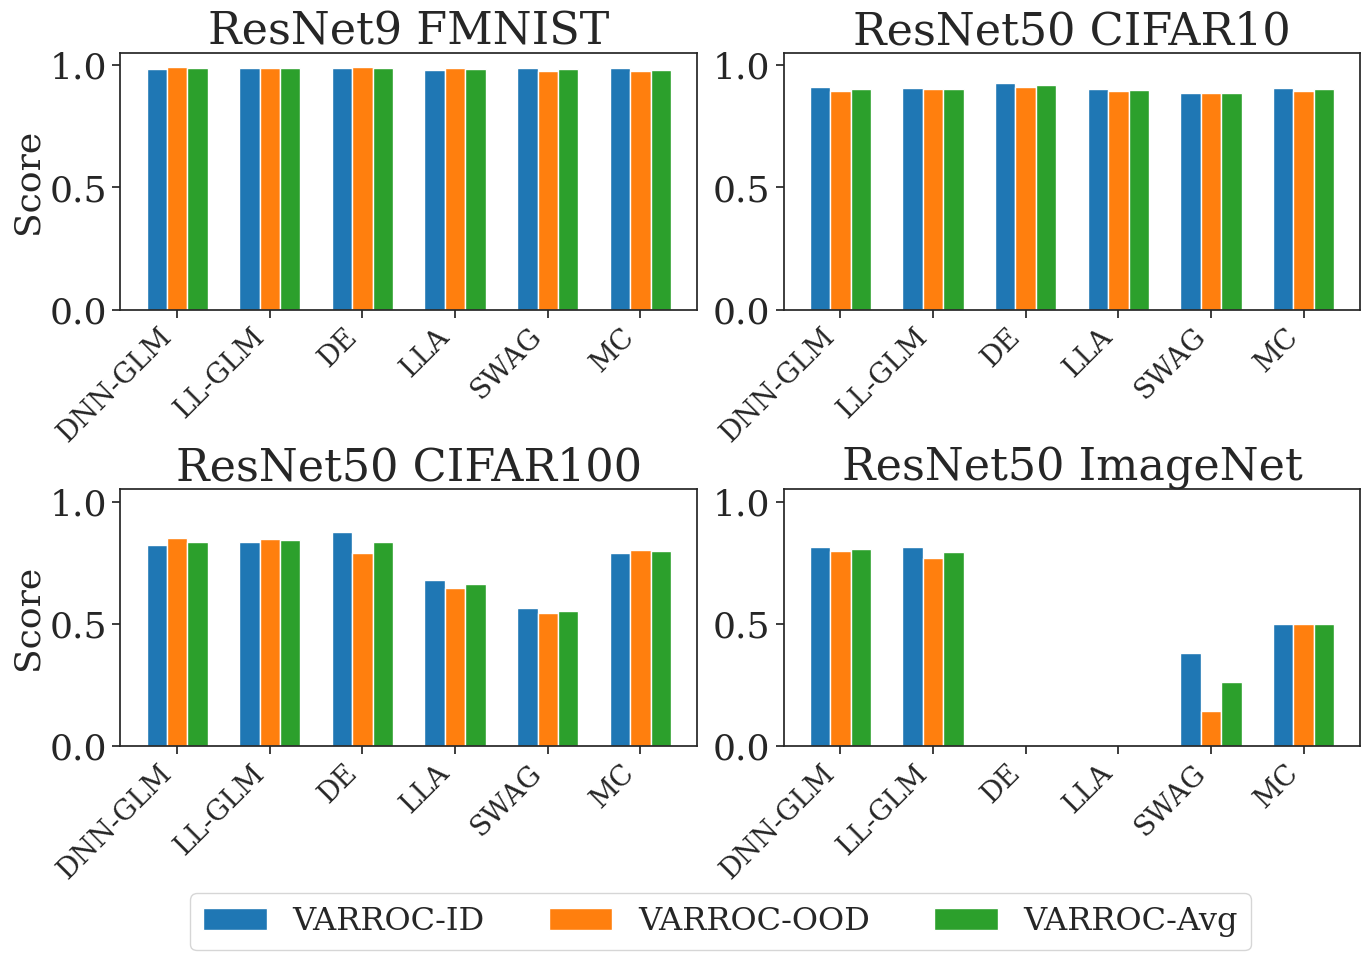

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import texplot

# ---- Data ------------------------------------
methods = ["DNN-GLM","LL-GLM","DE","LLA","SWAG","MC"]

datasets = {
    "ResNet9 FMNIST": [
        (0.9849,0.9941,0.9895),
        (0.9886,0.9892,0.9889),
        (0.9887,0.9916,0.9902),
        (0.9819,0.9882,0.9851),
        (0.9880,0.9774,0.9827),
        (0.9872,0.9756,0.9814),
    ],
    "ResNet50 CIFAR10": [
        (0.9100,0.8927,0.9014),
        (0.9086,0.9006,0.9046),
        (0.9277,0.9117,0.9197),
        (0.9034,0.8963,0.8999),
        (0.8855,0.8868,0.8862),
        (0.9072,0.8941,0.9007),
    ],
    "ResNet50 CIFAR100": [
        (0.8206,0.8504,0.8355),
        (0.8354,0.8479,0.8417),
        (0.8770,0.7900,0.8335),
        (0.6802,0.6452,0.6627),
        (0.5625,0.5422,0.5524),
        (0.7906,0.8012,0.7959),
    ],
    "ResNet50 ImageNet": [
        (0.8130,0.7980,0.8055),
        (0.8130,0.7710,0.7920),
        (None,None,None),
        (None,None,None),
        (0.3800,0.1450,0.2625),
        (0.5000,0.5000,0.5000),
    ],
}

metrics = ["VARROC-ID","VARROC-OOD","VARROC-Avg"]
width = 0.22
x = np.arange(len(methods))
fontsize = 26

with texplot.theme():
    # ---- Create 2×2 grid ----
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    plt.subplots_adjust(wspace=0.15, hspace=0.7)

    # Desired order
    order = [
        "ResNet9 FMNIST",
        "ResNet50 CIFAR10",
        "ResNet50 CIFAR100",
        "ResNet50 ImageNet"
    ]

    # ---- Plotting loop ----
    for ax, dataset in zip(axes.flatten(), order):
        triples = datasets[dataset]
        vals = np.array([[0 if v is None else v for v in t] for t in triples])

        # Plot V-ID, V-OOD, V-Avg
        for i in range(3):
            ax.bar(x + (i-1)*width, vals[:, i], width,
                label=metrics[i] if dataset == "ResNet50 ImageNet" else None)

        ax.set_title(dataset, fontsize=int(fontsize*1.25))
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=int(fontsize*0.8))
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='y', labelsize=fontsize)

    # Y-axis labels on left column
    axes[0][0].set_ylabel("Score", fontsize=fontsize)
    axes[1][0].set_ylabel("Score", fontsize=fontsize)

    # Legend only on bottom-right plot
    # axes[1][1].legend(loc="upper right", fontsize=fontsize)
    handles, labels = axes[1][1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.05), fontsize=int(fontsize*0.9))
    plt.subplots_adjust(bottom=0.25)
    plt.savefig('graphics/varroc_bar_plot.pdf', format='pdf', bbox_inches='tight')
    plt.show()
